# 33 — `sankey`

`Map.sankey` draws a **spatial flow map**: line features whose *width* is proportional to a magnitude. It is the
map for anything that moves along a network and accumulates — discharge down a river, traffic on roads, trade
between ports — because width is the channel a reader interprets as "how much" without being told.

Where `lines` encodes value in colour, `sankey` encodes it in thickness, which survives being printed in black
and white and reads correctly even at a glance.

API: [`Map.sankey`](../../reference/static_map.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

The same 36 Rhine reaches. We use `length` as the magnitude: longer reaches draw thicker. (In a real discharge
study the magnitude column would be flow; the plotting call is identical.)

In [2]:
rivers = FeatureCollection.read_file(str(DATA / "rhine_river_centerline.geojson"))
print(f"{len(rivers)} reaches, EPSG:{rivers.crs.to_epsg()}")
rivers["length"].describe()[["min", "50%", "max"]]

36 reaches, EPSG:3035


min      0.389358
50%      0.689701
max    204.712551
Name: length, dtype: float64

## Quickstart — width as magnitude

`column=` is the magnitude that sets each line's width.

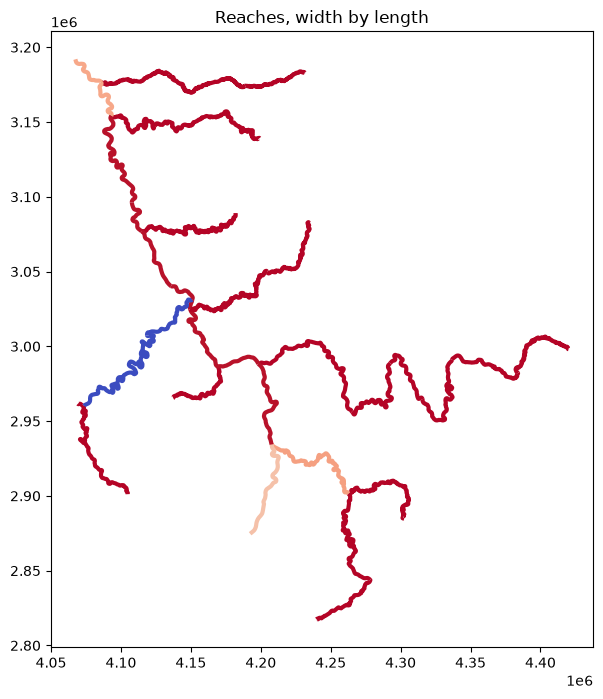

In [3]:
m = Map(crs=rivers.crs.to_epsg(), figsize=(7, 8))
m.sankey(rivers, column="length")
m.set_title("Reaches, width by length")
m.fig;

The long trunk reaches now read as the main channels and the short headwater reaches as threads. Compare this
with `32_lines`' colour ramp of the same column: the information is identical, but thickness is read
pre-attentively — you see the trunk before you decide to look for it.

## Width and colour together

`column` sets width; `scale` names the column driving colour, so one figure can carry two variables — or the
same one twice for emphasis.

| argument | meaning | typical value |
|---|---|---|
| `features` | the line collection | a line `FeatureCollection` |
| `column` | magnitude driving **width** | a numeric column |
| `scale` | column driving **colour** | often the same column |

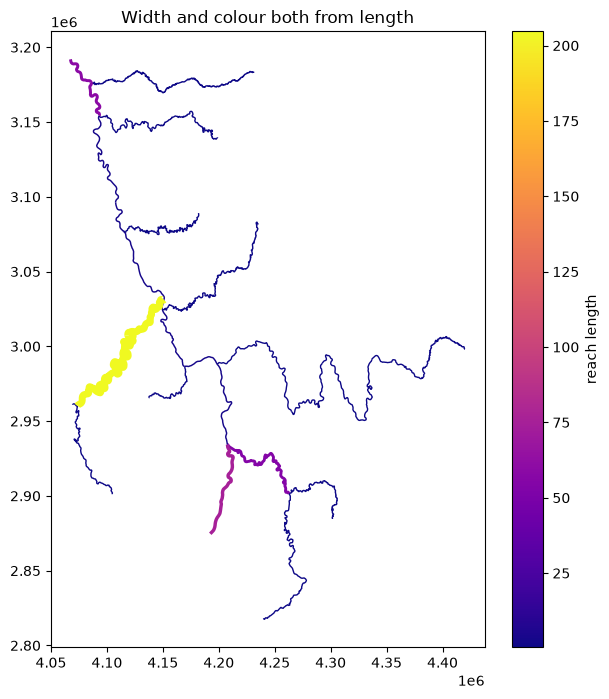

In [4]:
m = Map(crs=rivers.crs.to_epsg(), figsize=(7, 8))
m.sankey(rivers, column="length", scale="length", cmap="plasma")
m.colorbar(label="reach length")
m.set_title("Width and colour both from length")
m.fig;

Doubling up width and colour on one variable is redundant encoding, and that is a feature: it makes the figure
robust. A reader who cannot distinguish the colours still sees the thickness, and vice versa.

## Takeaway

- `sankey` puts magnitude in **line width**, the channel readers interpret as quantity without instruction.
- `column` drives width, `scale` drives colour; use both on one variable for redundancy or on two to layer them.
- Prefer `sankey` over `lines(column=...)` whenever the value is a *flow* rather than a label or a class.

Next: [`34_labels`](34_labels.ipynb) puts text from an attribute onto the map.